# Predictive Modeling of Cognitive Performance from Sleep Quality Metrics
CS 210: Data Management for Data Science | Anton Lyan | Rutgers University - New Brunswick | at1444@scarletmail.rutgers.edu

# Project Overview
This project builds an end-to-end data pipeline that collects, stores, and analyzes sleep quality data to predict cognitive performance scores. Rather than relying on simple sleep duration measures, we examine multiple sleep dimensions — REM sleep, deep sleep, sleep latency, wake episodes — alongside lifestyle covariates to build interpretable regression models.

**Target Variable:** cognitive_performance_score (continuous, 0–100)  
**Dataset:** 100,000 sleep health observations with 31 features  
**Models:** Linear Regression (baseline), Ridge Regression, Lasso Regression


## Setup

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11
})
SEED = 42

## Load Data

In [2]:
df = pd.read_csv('sleep_health_dataset.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn overview:")
print(df.dtypes.to_string())

Dataset shape: 100,000 rows × 32 columns

Column overview:
person_id                        int64
age                              int64
gender                          object
occupation                      object
bmi                            float64
country                         object
sleep_duration_hrs             float64
sleep_quality_score            float64
rem_percentage                 float64
deep_sleep_percentage          float64
sleep_latency_mins               int64
wake_episodes_per_night          int64
caffeine_mg_before_bed           int64
alcohol_units_before_bed       float64
screen_time_before_bed_mins      int64
exercise_day                     int64
steps_that_day                   int64
nap_duration_mins                int64
stress_score                   float64
work_hours_that_day            float64
chronotype                      object
mental_health_condition         object
heart_rate_resting_bpm           int64
sleep_aid_used                   int64
shift

In [3]:
df.head(5)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [4]:
# Statistical summary of features
df.describe().round(2)

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,...,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50000.50,34.71,26.29,6.42,4.87,20.24,20.25,19.84,3.35,38.85,...,14.94,5.73,7.13,66.57,0.56,0.08,20.54,1.20,59.23,0.39
std,28867.66,11.04,4.48,1.27,1.51,3.41,4.25,7.58,1.92,69.40,...,21.39,1.62,3.48,7.23,0.50,0.28,2.90,0.79,22.25,0.49
min,1.00,18.00,16.00,3.00,1.00,10.00,5.00,1.00,0.00,0.00,...,0.00,1.00,0.00,45.00,0.00,0.00,15.00,-1.00,0.00,0.00
25%,25000.75,26.00,23.20,5.53,3.80,18.00,17.40,14.00,2.00,0.00,...,0.00,4.80,4.70,62.00,0.00,0.00,18.50,0.67,44.20,0.00
50%,50000.50,33.00,26.30,6.36,4.90,20.30,20.30,19.00,3.00,0.00,...,0.00,5.80,7.40,67.00,1.00,0.00,20.50,1.20,60.40,0.00
75%,75000.25,42.00,29.30,7.27,6.00,22.60,23.20,25.00,5.00,80.00,...,30.00,6.80,9.70,71.00,1.00,0.00,22.50,1.74,75.80,1.00
max,100000.00,69.00,45.00,10.50,10.00,30.00,30.00,58.00,8.00,400.00,...,116.00,10.00,18.00,99.00,1.00,1.00,28.00,3.00,100.00,1.00


In [5]:
#Missing Values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values")
print(f"\nDuplicate rows: {df.duplicated().sum():,}")
print(f"\nTarget variable distribution:")
print(df['cognitive_performance_score'].describe().round(2))

Missing values per column:
No missing values

Duplicate rows: 0

Target variable distribution:
count    100000.00
mean         59.23
std          22.25
min           0.00
25%          44.20
50%          60.40
75%          75.80
max         100.00
Name: cognitive_performance_score, dtype: float64


## Data Cleaning/Preprocessing

**Schema Structure**
- **Drop leakage/outcome columns**: sleep_disorder_risk and felt_rested are concurrent outcomes, not predictors
- **Drop identifier**: person_id carries no predictive information
- **Encode categoricals**: Use ordinal encoding for ordered categories, one-hot for nominal


In [6]:
#Dropping unuseful/non-predictive feature columns
drop_cols = ['person_id', 'sleep_disorder_risk', 'felt_rested']
df_clean = df.drop(columns=drop_cols).copy()

#Validation through detecting outliers using IQR
numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('cognitive_performance_score')  # don't filter on target

outlier_report = {}
for col in numeric_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < Q1 - 3*IQR) | (df_clean[col] > Q3 + 3*IQR)).sum()
    if n_out > 0:
        outlier_report[col] = n_out

print("Extreme outliers:")
if outlier_report:
    for k,v in outlier_report.items():
        print(f"  {k}: {v} rows ({v/len(df_clean)*100:.2f}%)")
else:
    print(f"No Outlierse Detected")


Extreme outliers:
  caffeine_mg_before_bed: 669 rows (0.67%)
  alcohol_units_before_bed: 706 rows (0.71%)
  heart_rate_resting_bpm: 1 rows (0.00%)
  shift_work: 8442 rows (8.44%)


In [7]:
#Categorical Features
ordinal_maps = {
    'chronotype':            {'Morning': 0, 'Neutral': 1, 'Evening': 2},
    'mental_health_condition': {'Healthy': 0, 'Anxiety': 1, 'Depression': 2, 'Both': 3},
    'season':                {'Spring': 0, 'Summer': 1, 'Autumn': 2, 'Winter': 3},
    'day_type':              {'Weekday': 0, 'Weekend': 1},
    'gender':                {'Female': 0, 'Male': 1, 'Other': 2},
}

for col, mapping in ordinal_maps.items():
    df_clean[col] = df_clean[col].map(mapping)

# One-hot encode unique  cols (occupation, country)
df_clean = pd.get_dummies(df_clean, columns=['occupation', 'country'], drop_first=True)

print(f"Shape after encoding: {df_clean.shape}")
print(f"  Original numeric features : {len(numeric_cols)}")
print(f"  After encoding + OHE      : {df_clean.shape[1] - 1} features + 1 target")

Shape after encoding: (100000, 52)
  Original numeric features : 21
  After encoding + OHE      : 51 features + 1 target


## Feature Engineering
Sleep Quality Features:
- sleep_debt: Deviation from the recommended 8-hour sleep baseline
- rem_ratio: Proportion of REM sleep within total structured sleep (REM + deep)
- sleep_fragmentation_index: Measures disrupted sleep


In [8]:
#Sleep debt from recommended 8-hour baseline
df_clean['sleep_debt'] = np.maximum(0, 8.0 - df_clean['sleep_duration_hrs'])

#REM to (REM + Deep) ratio
df_clean['rem_ratio'] = (
    df_clean['rem_percentage'] /
    (df_clean['rem_percentage'] + df_clean['deep_sleep_percentage'] + 1e-6)
)

#Sleep fragmentation index: captures disrupted sleep patterns
df_clean['sleep_fragmentation_index'] = (
    df_clean['wake_episodes_per_night'] * df_clean['sleep_latency_mins']
) / 100.0

print("Engineered features added:")
print("  sleep_debt               — hours below 8hr target")
print("  rem_ratio                — REM / (REM + Deep)")
print("  sleep_fragmentation_index — (wake_episodes × latency) / 100")
print(f"\nFinal dataset shape: {df_clean.shape}")

Engineered features added:
  sleep_debt               — hours below 8hr target
  rem_ratio                — REM / (REM + Deep)
  sleep_fragmentation_index — (wake_episodes × latency) / 100

Final dataset shape: (100000, 55)


## Relational Database Storage (SQLite)


In [9]:
#Create Database following Schema Design
conn = sqlite3.connect('sleep_cognitive.db')
cursor = conn.cursor()

cursor.executescript("""
    DROP TABLE IF EXISTS lifestyle_factors;
    DROP TABLE IF EXISTS sleep_sessions;
    DROP TABLE IF EXISTS participants;
""")

#Tables
#Participants Table
cursor.execute("""
    CREATE TABLE participants (
        person_id     INTEGER PRIMARY KEY,
        age           INTEGER,
        gender        TEXT,
        occupation    TEXT,
        bmi           REAL,
        country       TEXT,
        chronotype    TEXT,
        mental_health_condition TEXT,
        shift_work    INTEGER
    )
""")

#Sleep sessions table
cursor.execute("""
    CREATE TABLE sleep_sessions (
        session_id              INTEGER PRIMARY KEY AUTOINCREMENT,
        person_id               INTEGER,
        sleep_duration_hrs      REAL,
        sleep_quality_score     REAL,
        rem_percentage          REAL,
        deep_sleep_percentage   REAL,
        sleep_latency_mins      INTEGER,
        wake_episodes_per_night INTEGER,
        sleep_aid_used          INTEGER,
        weekend_sleep_diff_hrs  REAL,
        nap_duration_mins       INTEGER,
        cognitive_performance_score REAL,
        FOREIGN KEY (person_id) REFERENCES participants(person_id)
    )
""")

#Lifestyle factors table
cursor.execute("""
    CREATE TABLE lifestyle_factors (
        factor_id                   INTEGER PRIMARY KEY AUTOINCREMENT,
        person_id                   INTEGER,
        caffeine_mg_before_bed      INTEGER,
        alcohol_units_before_bed    REAL,
        screen_time_before_bed_mins INTEGER,
        exercise_day                INTEGER,
        steps_that_day              INTEGER,
        stress_score                REAL,
        work_hours_that_day         REAL,
        heart_rate_resting_bpm      INTEGER,
        room_temperature_celsius    REAL,
        season                      TEXT,
        day_type                    TEXT,
        FOREIGN KEY (person_id) REFERENCES participants(person_id)
    )
""")

conn.commit()

In [10]:
#Load raw CSV data into the database
df_raw = pd.read_csv('sleep_health_dataset.csv')

participants = df_raw[['person_id','age','gender','occupation','bmi','country',
                        'chronotype','mental_health_condition','shift_work']]
participants.to_sql('participants', conn, if_exists='append', index=False)

sleep_cols = ['person_id','sleep_duration_hrs','sleep_quality_score','rem_percentage',
              'deep_sleep_percentage','sleep_latency_mins','wake_episodes_per_night',
              'sleep_aid_used','weekend_sleep_diff_hrs','nap_duration_mins',
              'cognitive_performance_score']
df_raw[sleep_cols].to_sql('sleep_sessions', conn, if_exists='append', index=False)

lifestyle_cols = ['person_id','caffeine_mg_before_bed','alcohol_units_before_bed',
                  'screen_time_before_bed_mins','exercise_day','steps_that_day',
                  'stress_score','work_hours_that_day','heart_rate_resting_bpm',
                  'room_temperature_celsius','season','day_type']
df_raw[lifestyle_cols].to_sql('lifestyle_factors', conn, if_exists='append', index=False)

conn.commit()
print(f"Loaded {len(df_raw):,} rows into database")

#Row COunt
for table in ['participants', 'sleep_sessions', 'lifestyle_factors']:
    n = pd.read_sql(f"SELECT COUNT(*) as n FROM {table}", conn)['n'][0]
    print(f"  {table}: {n:,} rows")

Loaded 100,000 rows into database
  participants: 100,000 rows
  sleep_sessions: 100,000 rows
  lifestyle_factors: 100,000 rows


In [11]:
#Query Data for Analysis
query = """
    SELECT 
        p.age, p.gender, p.bmi, p.chronotype, p.mental_health_condition,
        p.shift_work,
        s.sleep_duration_hrs, s.sleep_quality_score, s.rem_percentage,
        s.deep_sleep_percentage, s.sleep_latency_mins, s.wake_episodes_per_night,
        s.sleep_aid_used, s.weekend_sleep_diff_hrs, s.nap_duration_mins,
        s.cognitive_performance_score,
        l.caffeine_mg_before_bed, l.alcohol_units_before_bed,
        l.screen_time_before_bed_mins, l.exercise_day, l.steps_that_day,
        l.stress_score, l.work_hours_that_day, l.heart_rate_resting_bpm,
        l.room_temperature_celsius, l.season, l.day_type,
        p.occupation, p.country
    FROM sleep_sessions s
    JOIN participants p ON s.person_id = p.person_id
    JOIN lifestyle_factors l ON s.person_id = l.person_id
"""

df_queried = pd.read_sql(query, conn)
print(f"Queried {len(df_queried):,} rows from normalized database")
print(f"Columns: {list(df_queried.columns)}")

Queried 100,000 rows from normalized database
Columns: ['age', 'gender', 'bmi', 'chronotype', 'mental_health_condition', 'shift_work', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'sleep_aid_used', 'weekend_sleep_diff_hrs', 'nap_duration_mins', 'cognitive_performance_score', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'room_temperature_celsius', 'season', 'day_type', 'occupation', 'country']


## Data Analysis

In [ ]:
#Distributions/Visualizations
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Cognitive Performance Score — Target Variable', fontsize=14, fontweight='bold')

axes[0].hist(df_queried['cognitive_performance_score'], bins=50, color='#4C72B0', 
             edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Cognitive Performance Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution')

stats_vals = df_queried['cognitive_performance_score']
axes[0].axvline(stats_vals.mean(), color='red', linestyle='--', label=f'Mean={stats_vals.mean():.1f}')
axes[0].axvline(stats_vals.median(), color='orange', linestyle='--', label=f'Median={stats_vals.median():.1f}')
axes[0].legend()

stats.probplot(df_queried['cognitive_performance_score'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()
print(f"Skewness: {stats_vals.skew():.3f}")

In [ ]:
#Correlation: sleep metrics vs target
sleep_vars = ['sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
              'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night',
              'stress_score', 'work_hours_that_day', 'exercise_day',
              'alcohol_units_before_bed', 'caffeine_mg_before_bed',
              'screen_time_before_bed_mins', 'cognitive_performance_score']

corr_matrix = df_queried[sleep_vars].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix: Sleep Metrics & Lifestyle vs Cognitive Performance',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [ ]:
#Scatterplot of Predictors
key_features = {
    'sleep_quality_score': ('Sleep Quality Score (0-10)', '#4C72B0'),
    'sleep_duration_hrs': ('Sleep Duration (hrs)', '#55A868'),
    'stress_score': ('Stress Score', '#C44E52'),
    'rem_percentage': ('REM Sleep %', '#8172B2'),
    'wake_episodes_per_night': ('Wake Episodes / Night', '#CCB974'),
    'work_hours_that_day': ('Work Hours', '#64B5CD'),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Key Predictors vs Cognitive Performance Score', fontsize=14, fontweight='bold')

for ax, (feat, (label, color)) in zip(axes.flat, key_features.items()):
    sample = df_queried.sample(3000, random_state=SEED)
    ax.scatter(sample[feat], sample['cognitive_performance_score'],
               alpha=0.2, s=8, color=color)
    # Add regression line
    m, b = np.polyfit(df_queried[feat], df_queried['cognitive_performance_score'], 1)
    x_line = np.linspace(df_queried[feat].min(), df_queried[feat].max(), 100)
    ax.plot(x_line, m*x_line + b, 'k-', linewidth=2)
    r = df_queried[[feat, 'cognitive_performance_score']].corr().iloc[0,1]
    ax.set_xlabel(label)
    ax.set_ylabel('Cognitive Score')
    ax.set_title(f'r = {r:.3f}')

plt.tight_layout()
plt.show()

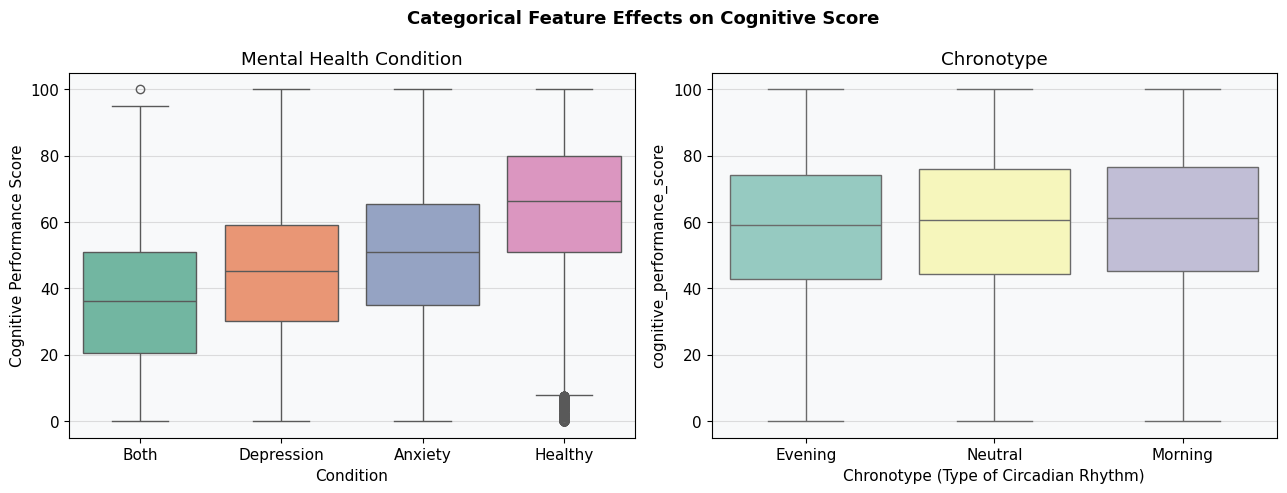

In [15]:
#Categorical Feature Visualizations
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Categorical Feature Effects on Cognitive Score', fontsize=13, fontweight='bold')

order_mh = df_queried.groupby('mental_health_condition')['cognitive_performance_score'].median().sort_values().index
sns.boxplot(data=df_queried, x='mental_health_condition', y='cognitive_performance_score',
            order=order_mh, palette='Set2', ax=axes[0])
axes[0].set_title('Mental Health Condition')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Cognitive Performance Score')

order_ct = df_queried.groupby('chronotype')['cognitive_performance_score'].median().sort_values().index
sns.boxplot(data=df_queried, x='chronotype', y='cognitive_performance_score',
            order=order_ct, palette='Set3', ax=axes[1])
axes[1].set_title('Chronotype')
axes[1].set_xlabel('Chronotype (Type of Circadian Rhythm)')

plt.tight_layout()
plt.show()

## Feature Matrix

We prepare two feature sets:
- Full set (all predictors including sleep_quality_score) 
- Sleep-metrics-only (excluding sleep_quality_score): isolates the impact of raw sleep variables, which is the core research question


In [16]:
#Feature Engineering
df_model = df_queried.copy()

df_model['sleep_debt'] = np.maximum(0, 8.0 - df_model['sleep_duration_hrs'])
df_model['rem_ratio']  = (df_model['rem_percentage'] /
                          (df_model['rem_percentage'] + df_model['deep_sleep_percentage'] + 1e-6))
df_model['sleep_fragmentation_index'] = (
    df_model['wake_episodes_per_night'] * df_model['sleep_latency_mins']
) / 100.0

#Categorical Encoding
ordinal_maps = {
    'chronotype':             {'Morning': 0, 'Neutral': 1, 'Evening': 2},
    'mental_health_condition':{'Healthy': 0, 'Anxiety': 1, 'Depression': 2, 'Both': 3},
    'season':                 {'Spring': 0, 'Summer': 1, 'Autumn': 2, 'Winter': 3},
    'day_type':               {'Weekday': 0, 'Weekend': 1},
    'gender':                 {'Female': 0, 'Male': 1, 'Other': 2},
}
for col, mapping in ordinal_maps.items():
    df_model[col] = df_model[col].map(mapping)

df_model = pd.get_dummies(df_model, columns=['occupation', 'country'], drop_first=True)

TARGET = 'cognitive_performance_score'
y = df_model[TARGET]

# Full feature set (includes sleep_quality_score)
X_full = df_model.drop(columns=[TARGET])
# Sleep-metrics-only (no quality score)
X_raw  = df_model.drop(columns=[TARGET, 'sleep_quality_score'])

print(f"Full feature set: {X_full.shape[1]} features")
print(f"Sleep-metrics-only set: {X_raw.shape[1]} features")
print(f"\nBest feature correlations with target:")
eng_cols = ['sleep_debt','rem_ratio','sleep_fragmentation_index']
for c in eng_cols:
    print(f"  {c}: r = {df_model[[c, TARGET]].corr().iloc[0,1]:.4f}")

Full feature set: 54 features
Sleep-metrics-only set: 53 features

Best feature correlations with target:
  sleep_debt: r = -0.6676
  rem_ratio: r = 0.0617
  sleep_fragmentation_index: r = -0.3481


In [17]:
#Train/Test Split - divided by quartile to maintain distribution (80/20 split)
y_quartile = pd.qcut(y, 4, labels=False)

X_train_f, X_test_f, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=SEED, stratify=y_quartile)

X_train_r, X_test_r, _, _ = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED, stratify=y_quartile)

# Scale features for Ridge/Lasso Regression
scaler_f = StandardScaler()
X_train_f_s = scaler_f.fit_transform(X_train_f)
X_test_f_s  = scaler_f.transform(X_test_f)

scaler_r = StandardScaler()
X_train_r_s = scaler_r.fit_transform(X_train_r)
X_test_r_s  = scaler_r.transform(X_test_r)

print(f"Training set:  {X_train_f_s.shape[0]:,} samples")
print(f"Test set:      {X_test_f_s.shape[0]:,} samples")
print(f"\nTarget distribution preserved:")
print(f"  Train mean: {y_train.mean():.2f} ± {y_train.std():.2f}")
print(f"  Test mean:  {y_test.mean():.2f} ± {y_test.std():.2f}")

Training set:  80,000 samples
Test set:      20,000 samples

Target distribution preserved:
  Train mean: 59.25 ± 22.21
  Test mean:  59.15 ± 22.42


## Model Training & Evaluation
Regression Models:
1. Linear Regression — baseline, no regularization
2. Ridge Regression (L2) — retains all features, shrinks large coefficients; best when many weak predictors are present
3. Lasso Regression (L1) — performs implicit feature selection by zeroing weak predictors

Train both on the full feature set and sleep-metrics-only(raw) set to answer the research question


In [18]:
def evaluate_model(model, X_train, X_test, y_train, y_test, cv_folds=5, name='Model'):
    """Train model, run 5-fold CV, and compute test-set metrics."""
    # 5-fold CV on training data
    kf  = KFold(n_splits=cv_folds, shuffle=True, random_state=SEED)
    cv_results = cross_validate(model, X_train, y_train, cv=kf,
                                scoring=['neg_mean_absolute_error',
                                         'neg_root_mean_squared_error',
                                         'r2'],
                                return_train_score=True)
    
    cv_mae  = -cv_results['test_neg_mean_absolute_error']
    cv_rmse = -cv_results['test_neg_root_mean_squared_error']
    cv_r2   =  cv_results['test_r2']

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    test_mae  = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2   = r2_score(y_test, y_pred)
    
    print(f" {name}")
    print(f" 5-Fold CV  -  MAE: {cv_mae.mean():.3f} ± {cv_mae.std():.3f}  "
          f"RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}  "
          f"R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f" Test Set  -  MAE: {test_mae:.3f}  "
          f"RMSE: {test_rmse:.3f}  R²: {test_r2:.4f}")
    
    return {
        'name': name, 'model': model, 'y_pred': y_pred,
        'cv_mae': cv_mae, 'cv_rmse': cv_rmse, 'cv_r2': cv_r2,
        'test_mae': test_mae, 'test_rmse': test_rmse, 'test_r2': test_r2
    }


In [19]:
#Feature Set
from sklearn.linear_model import Ridge, Lasso

print("'Full' Feature Set")

res_lr_full = evaluate_model(LinearRegression(),
                             X_train_f_s, X_test_f_s, y_train, y_test,
                             name='Linear Regression')

res_ridge_full = evaluate_model(Ridge(alpha=1.0),
                                X_train_f_s, X_test_f_s, y_train, y_test,
                                name='Ridge Regression')

res_lasso_full = evaluate_model(Lasso(alpha=0.01, max_iter=1000),
                                X_train_f_s, X_test_f_s, y_train, y_test,
                                name='Lasso Regression')

print(f"\nBest Ridge: {res_ridge_full['model'].alpha}")
print(f"Best Lasso: {res_lasso_full['model'].alpha}")

'Full' Feature Set
 Linear Regression
 5-Fold CV  -  MAE: 4.725 ± 0.008  RMSE: 5.922 ± 0.013  R²: 0.9289 ± 0.0005
 Test Set  -  MAE: 4.716  RMSE: 5.918  R²: 0.9303
 Ridge Regression
 5-Fold CV  -  MAE: 4.725 ± 0.008  RMSE: 5.922 ± 0.013  R²: 0.9289 ± 0.0005
 Test Set  -  MAE: 4.716  RMSE: 5.918  R²: 0.9303
 Lasso Regression
 5-Fold CV  -  MAE: 4.725 ± 0.008  RMSE: 5.922 ± 0.013  R²: 0.9289 ± 0.0005
 Test Set  -  MAE: 4.717  RMSE: 5.918  R²: 0.9303

Best Ridge: 1.0
Best Lasso: 0.01


In [20]:
#Sleep-Metric only model
print("SLEEP METRICS ONLY (no quality score, 'raw' set)")

res_lr_raw = evaluate_model(LinearRegression(),
                            X_train_r_s, X_test_r_s, y_train, y_test,
                            name='Linear Regression')

res_ridge_raw = evaluate_model(Ridge(alpha=1.0),
                               X_train_r_s, X_test_r_s, y_train, y_test,
                               name='Ridge Regression')

res_lasso_raw = evaluate_model(Lasso(alpha=0.01, max_iter=1000),
                               X_train_r_s, X_test_r_s, y_train, y_test,
                               name='Lasso Regression')

SLEEP METRICS ONLY (no quality score, 'raw' set)
 Linear Regression
 5-Fold CV  -  MAE: 5.991 ± 0.006  RMSE: 7.495 ± 0.020  R²: 0.8861 ± 0.0009
 Test Set  -  MAE: 5.994  RMSE: 7.484  R²: 0.8885
 Ridge Regression
 5-Fold CV  -  MAE: 5.991 ± 0.006  RMSE: 7.495 ± 0.020  R²: 0.8861 ± 0.0009
 Test Set  -  MAE: 5.994  RMSE: 7.484  R²: 0.8885
 Lasso Regression
 5-Fold CV  -  MAE: 5.992 ± 0.006  RMSE: 7.495 ± 0.019  R²: 0.8861 ± 0.0009
 Test Set  -  MAE: 5.994  RMSE: 7.483  R²: 0.8885


## Results Comparison & Visualization

In [21]:
#Summary
results_data = []
for res in [res_lr_full, res_ridge_full, res_lasso_full,
            res_lr_raw,  res_ridge_raw,  res_lasso_raw]:
    results_data.append({
        'Model': res['name'],
        'CV MAE':  f"{res['cv_mae'].mean():.3f} ± {res['cv_mae'].std():.3f}",
        'CV RMSE': f"{res['cv_rmse'].mean():.3f} ± {res['cv_rmse'].std():.3f}",
        'CV R²':   f"{res['cv_r2'].mean():.4f} ± {res['cv_r2'].std():.4f}",
        'Test MAE':  round(res['test_mae'], 3),
        'Test RMSE': round(res['test_rmse'], 3),
        'Test R²':   round(res['test_r2'], 4),
    })

results_df = pd.DataFrame(results_data)
pd.set_option('display.max_colwidth', 60)
results_df

,Model,CV MAE,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²
0,Linear Regression,4.725 ± 0.008,5.922 ± 0.013,0.9289 ± 0.0005,4.716,5.918,0.9303
1,Ridge Regression,4.725 ± 0.008,5.922 ± 0.013,0.9289 ± 0.0005,4.716,5.918,0.9303
2,Lasso Regression,4.725 ± 0.008,5.922 ± 0.013,0.9289 ± 0.0005,4.717,5.918,0.9303
3,Linear Regression,5.991 ± 0.006,7.495 ± 0.020,0.8861 ± 0.0009,5.994,7.484,0.8885
4,Ridge Regression,5.991 ± 0.006,7.495 ± 0.020,0.8861 ± 0.0009,5.994,7.484,0.8885
5,Lasso Regression,5.992 ± 0.006,7.495 ± 0.019,0.8861 ± 0.0009,5.994,7.483,0.8885


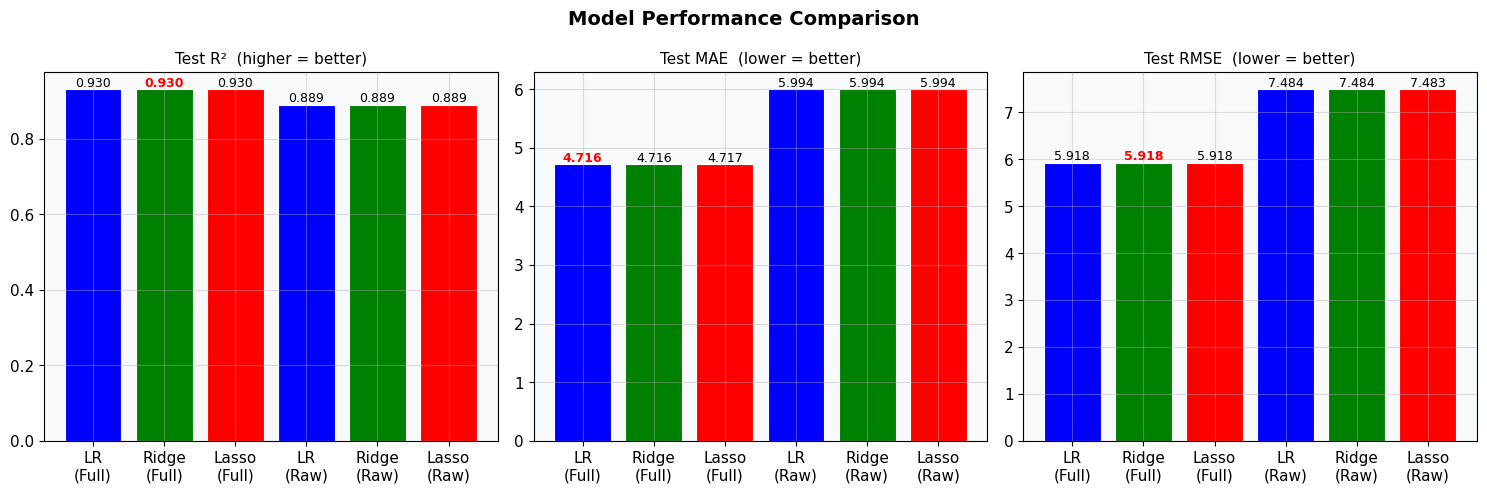

In [22]:
#Model Comparison - Bar Chart
model_labels = ['LR\n(Full)', 'Ridge\n(Full)', 'Lasso\n(Full)',
                'LR\n(Raw)', 'Ridge\n(Raw)', 'Lasso\n(Raw)']
r2_vals  = [r['test_r2'] for r in [res_lr_full,res_ridge_full,res_lasso_full,
                                    res_lr_raw, res_ridge_raw, res_lasso_raw]]
mae_vals = [r['test_mae'] for r in [res_lr_full,res_ridge_full,res_lasso_full,
                                     res_lr_raw, res_ridge_raw, res_lasso_raw]]
rmse_vals= [r['test_rmse'] for r in [res_lr_full,res_ridge_full,res_lasso_full,
                                      res_lr_raw, res_ridge_raw, res_lasso_raw]]

colors = ['Blue','Green','Red']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

for ax, vals, title, best_fn in zip(
        axes,
        [r2_vals, mae_vals, rmse_vals],
        ['Test R²  (higher = better)', 'Test MAE  (lower = better)', 'Test RMSE  (lower = better)'],
        [max, min, min]):
    bars = ax.bar(model_labels, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=11)
    best_val = best_fn(vals)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9,
                fontweight='bold' if val == best_val else 'normal',
                color='red' if val == best_val else 'black')

plt.tight_layout()
plt.show()

## Residual Diagnostics
Four residual checks per model to verify regression assumptions:
1. Residuals vs Fitted — check for heteroscedasticity (non-constant variance)
2. Q-Q Plot — check normality of residuals
3. Scale-Location — detect variance trends
4. Residual distribution — overall error shape


In [ ]:
def residual_diagnostics(y_test, y_pred, model_name):
    """4-panel residual diagnostic plot."""
    residuals     = y_test.values - y_pred
    std_residuals = residuals / residuals.std()
    
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(f'Residual Diagnostics — {model_name}', fontsize=13, fontweight='bold')
    gs  = gridspec.GridSpec(2, 2, figure=fig)
    
    # 1. Residuals vs Fitted
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_pred, residuals, alpha=0.15, s=5, color='#4C72B0')
    ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Fitted Values'); ax1.set_ylabel('Residuals')
    ax1.set_title('Residuals vs Fitted')
    
    # 2. Q-Q Plot
    ax2 = fig.add_subplot(gs[0, 1])
    stats.probplot(residuals, dist="norm", plot=ax2)
    ax2.set_title('Normal Q-Q Plot')
    
    # 3. Scale-Location (√|standardized residuals| vs fitted)
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.scatter(y_pred, np.sqrt(np.abs(std_residuals)), alpha=0.15, s=5, color='#55A868')
    ax3.set_xlabel('Fitted Values'); ax3.set_ylabel('√|Standardized Residuals|')
    ax3.set_title('Scale-Location (Homoscedasticity)')
    
    # 4. Residual distribution
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.hist(residuals, bins=60, color='#C44E52', edgecolor='white', linewidth=0.4)
    ax4.axvline(0, color='black', linestyle='--')
    ax4.set_xlabel('Residual'); ax4.set_ylabel('Count')
    ax4.set_title(f'Residual Distribution  (skew={pd.Series(residuals).skew():.3f})')
    
    plt.tight_layout()
    fname = f'fig_residuals_{model_name.replace(" ","_").replace("(","").replace(")","")}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    
    print(f"Mean residual:{residuals.mean():.4f} (ideally ≈ 0)")
    print(f"Residual std:{residuals.std():.4f}")
    print(f"Skewness:{pd.Series(residuals).skew():.4f}")
    _, p_norm = stats.shapiro(residuals[:5000])  # Shapiro-Wilk on 5k sample
    print(f"  p-value (5k sample): {p_norm:.4e}")

residual_diagnostics(y_test, res_ridge_full['y_pred'], 'Ridge Full')

In [ ]:
residual_diagnostics(y_test, res_ridge_raw['y_pred'], 'Ridge Sleep Metrics Only')

In [ ]:
#Prediction vs Actual Results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Predicted vs Actual Cognitive Performance', fontsize=13, fontweight='bold')

for ax, res, title in zip(axes,
    [res_ridge_full, res_ridge_raw],
    ['Ridge (Full Features)', 'Ridge (Sleep Metrics Only)']):
    ax.scatter(y_test, res['y_pred'], alpha=0.15, s=5, color='#4C72B0')
    lims = [0, 100]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Score'); ax.set_ylabel('Predicted Score')
    ax.set_title(f'{title}\nR² = {res["test_r2"]:.4f}')
    ax.legend()
    ax.set_xlim(lims); ax.set_ylim(lims)

plt.tight_layout()
plt.show()

## 11. Feature Importance & Interpretability

Regression coefficients represent the expected change in cognitive performance score per one standard-deviation increase in each predictor, allowing direct comparison across features with different scales.


In [ ]:
#Coefficient Comparison on Full Feature Set
feature_names_full = list(X_full.columns)
feature_names_raw  = list(X_raw.columns)

ridge_coef = pd.Series(res_ridge_full['model'].coef_, index=feature_names_full)
lasso_coef = pd.Series(res_lasso_full['model'].coef_, index=feature_names_full)

# Focus on sleep & lifestyle features (not OHE country/occupation dummies)
core_features = [f for f in feature_names_full 
                 if not f.startswith('occupation_') and not f.startswith('country_')]

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Standardized Regression Coefficients (Full Feature Set)', 
             fontsize=13, fontweight='bold')

for ax, coef, title, color_pos, color_neg in zip(
        axes,
        [ridge_coef[core_features], lasso_coef[core_features]],
        ['Ridge Regression', 'Lasso Regression'],
        ['#4C72B0', '#55A868'],
        ['#C44E52', '#C44E52']):
    coef_sorted = coef.sort_values()
    colors = [color_pos if v > 0 else color_neg for v in coef_sorted]
    coef_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Standardized Coefficient')

plt.tight_layout()
plt.show()

In [27]:
lasso_coef_raw = pd.Series(res_lasso_raw['model'].coef_, index=feature_names_raw)

n_zero    = (lasso_coef_raw == 0).sum()
n_nonzero = (lasso_coef_raw != 0).sum()

print(f"Lasso (Sleep Metrics Only) = {res_lasso_raw['model'].alpha:.4f}")
print(f"Features selected (non-zero): {n_nonzero}")
print(f"Features zeroed out: {n_zero}")

print("\nTop positive predictors (increased cognitive score)")
print(lasso_coef_raw[lasso_coef_raw > 0].sort_values(ascending=False).head(10).round(4).to_string())

print("\nTop negative predictors (decreased cognitive score)")
print(lasso_coef_raw[lasso_coef_raw < 0].sort_values().head(10).round(4).to_string())

print("\nFeatures eliminated by Lasso")
zeroed = lasso_coef_raw[lasso_coef_raw == 0].index.tolist()
print(zeroed if zeroed else "  None — all features retained")

Lasso (Sleep Metrics Only) = 0.0100
Features selected (non-zero): 40
Features zeroed out: 13

Top positive predictors (increased cognitive score)
rem_percentage                 5.1451
exercise_day                   3.9886
deep_sleep_percentage          2.6906
day_type                       1.4094
chronotype                     0.1602
screen_time_before_bed_mins    0.0694
occupation_Homemaker           0.0602
country_USA                    0.0487
occupation_Freelancer          0.0172
sleep_aid_used                 0.0162

Top negative predictors (decreased cognitive score)
sleep_debt                 -24.2217
sleep_duration_hrs         -14.4123
mental_health_condition     -6.2263
stress_score                -5.1086
wake_episodes_per_night     -3.1428
alcohol_units_before_bed    -2.5966
shift_work                  -1.8882
sleep_latency_mins          -1.4101
caffeine_mg_before_bed      -0.7799
occupation_Retired          -0.2147

Features eliminated by Lasso
['steps_that_day', 'work_hours_

In [ ]:
#Top Predictors Bar Chart
top_n = 15
lasso_abs = lasso_coef_raw.abs().sort_values(ascending=False).head(top_n)
colors = ['Pink' if lasso_coef_raw[i] > 0 else 'Green' for i in lasso_abs.index]

fig, ax = plt.subplots(figsize=(10, 6))
lasso_abs.sort_values().plot(kind='barh', ax=ax, color=list(reversed(colors)),
                              edgecolor='white', linewidth=0.5)
ax.set_title(f'Top {top_n} Predictors by Lasso — Sleep Metrics Set',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Standardized Coefficient')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='Green', label='Positive effect (increased cognition)'),
                Patch(facecolor='Pink', label='Negative effect (decreased cognition)')]
ax.legend(handles=legend_elems, loc='lower right')

plt.tight_layout()
plt.savefig('fig9_top_predictors.png', dpi=150, bbox_inches='tight')
plt.show()